In [5]:
import pandas as pd
df = pd.read_csv('../../course_assignments/homework8/state_data.csv')

In [6]:
print(df.shape)
#52 rows, 4 columns

(52, 4)


In [7]:
print(df.head())
print(df.tail())
# The different columns represent the geographical coordinates of US states
# The first state is Alaska
# The last state is Wyoming
# 52 entries total
# District of Columbia and Puerto Rico is also listed

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [11]:
median_lat = df['latitude'].median(skipna = True)
median_long = df['longitude'].median(skipna = True)
print(median_lat)
print(median_long)

39.4355155
-89.093198


In [18]:
df['absdistlat'] = (df['latitude'] - median_lat).abs()
df['absdistlong'] = (df['longitude'] - median_long).abs()
print(df.shape)
# Same amount of rows, but now I have 7 columns

(52, 7)


In [41]:
closestlat = df['absdistlat'].idxmin()
print("Closest lat is", df.loc[closestlat, 'name'], "by", f"{closestlat:.2f}")
farthestlat = df['absdistlat'].idxmax()
print("Farthest lat is", df.loc[farthestlat, 'name'], "by", f"{farthestlat:.2f}")
closestlong = df['absdistlong'].idxmin()
print("Closest long is", df.loc[closestlong, 'name'], "by", f"{closestlong:.2f}")
farthestlong = df['absdistlong'].idxmax()
print("Farthest long is", df.loc[farthestlong, 'name'], "by", f"{farthestlong:.2f}")

Closest lat is Colorado by 5.00
Farthest lat is Alaska by 0.00
Closest long is Illinois by 14.00
Farthest long is Hawaii by 11.00


In [46]:
spintest = df.explode('name', ignore_index = True)
print(spintest)
# Explode would only be useful if there was a list of names in the name columns

   state   latitude   longitude                  name    absdist  absdistlat  \
0     AK  63.588753 -154.493062                Alaska  24.153237   24.153237   
1     AL  32.318231  -86.902298               Alabama   7.117285    7.117285   
2     AR  35.201050  -91.831833              Arkansas   4.234465    4.234465   
3     AZ  34.048928 -111.093731               Arizona   5.386588    5.386588   
4     CA  36.778261 -119.417932            California   2.657255    2.657255   
5     CO  39.550051 -105.782067              Colorado   0.114536    0.114536   
6     CT  41.603221  -73.087749           Connecticut   2.167705    2.167705   
7     DC  38.905985  -77.033418  District of Columbia   0.529530    0.529530   
8     DE  38.910832  -75.527670              Delaware   0.524684    0.524684   
9     FL  27.664827  -81.515754               Florida  11.770689   11.770689   
10    GA  32.157435  -82.907123               Georgia   7.278081    7.278081   
11    HI  19.898682 -155.665857         

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')
(344, 7)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
338  Gentoo  Biscoe            47.2           13.7              214.0   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4      

C:\Users\tinpo\AppData\Local\Temp\ipykernel_34636\796603999.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_clean, x = 'island', y = 'body_mass_g', ax = axes[1,1], palette = "Set2")


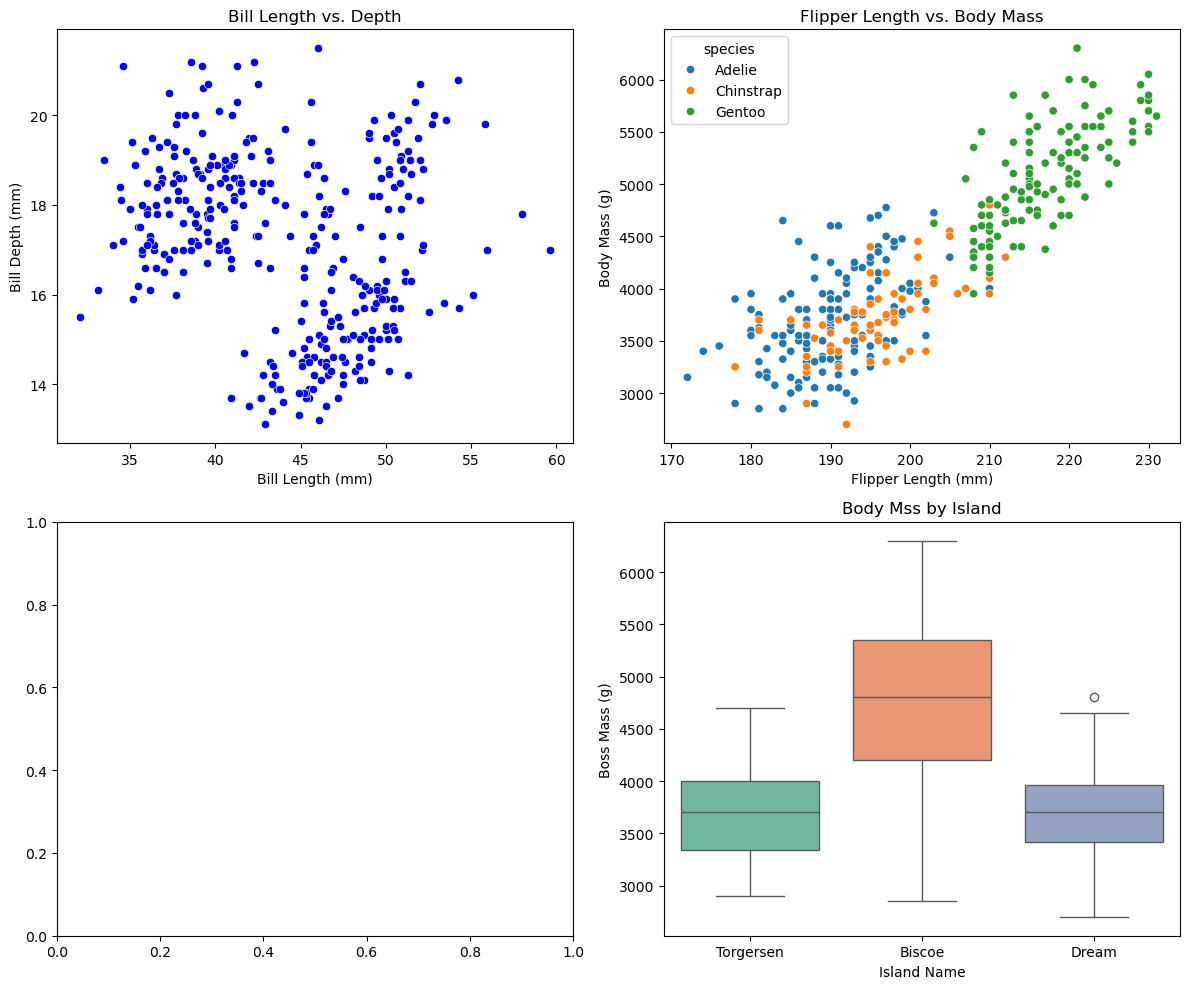

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

dataframe = sns.load_dataset("penguins")
df_clean = dataframe.dropna(axis = 0, how = 'any')
print(df_clean.columns)
print(dataframe.shape)
# There of 344 rows and 7 columns
print(df_clean.head(5))
print(df_clean.tail(5))
#First column is species (showing the species of penguin), the second column is the islands these penguins are located in.
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
sns.scatterplot(data = df_clean, x = 'bill_length_mm', y = 'bill_depth_mm', ax = axes[0,0], color = 'blue')
axes[0,0].set_title("Bill Length vs. Depth")
axes[0,0].set_xlabel("Bill Length (mm)")
axes[0,0].set_ylabel("Bill Depth (mm)")
sns.scatterplot(data = df_clean, x = 'flipper_length_mm', y = 'body_mass_g', hue = 'species', ax = axes[0,1])
axes[0,1].set_title("Flipper Length vs. Body Mass")
axes[0,1].set_xlabel("Flipper Length (mm)")
axes[0,1].set_ylabel("Body Mass (g)")
sns.boxplot(data = df_clean, x = 'island', y = 'body_mass_g', ax = axes[1,1], palette = "Set2")
axes[1,1].set_title("Body Mass by Island")
axes[1,1].set_xlabel("Island Name")
axes[1,1].set_ylabel("Boss Mass (g)")

plt.tight_layout()
plt.show()

# Bill Length vs Depth -- to see if there is a relationship -- does longer beaks equal shortness or does short beaks equal deep ones (seems irrelevant with the data now)
# Body Mass vs Flipper Length (Do longer flippers in any significant way add to the total body weight -- apparently so)
# Body Mass vs Island (see the weight differences amongst penguins on island -- which ones get more nutrients and foods on which location
# I learned different kind of penguins have longer flippers/body weights, with islands playing a factor into their body masses as well